In [1]:
import subprocess, sys

packages = ["pandas", "numpy", "scikit-learn", "matplotlib", "seaborn", "joblib"]

for pkg in packages:
    result = subprocess.run(
        [sys.executable, "-m", "pip", "install", pkg, "-q"],
        capture_output=True, text=True
    )
    print(f"  {'✅' if result.returncode == 0 else '❌'} {pkg}")

print("\nDone.")

  ✅ pandas
  ✅ numpy
  ✅ scikit-learn
  ✅ matplotlib
  ✅ seaborn
  ✅ joblib

Done.


In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix, roc_curve
)

print("✅ All imports successful.")

✅ All imports successful.


In [3]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

print(f"Shape  : {df.shape}")
print(f"Columns: {list(df.columns)}")
print(f"\nFirst 3 rows:")
df.head(3)

Shape  : (7043, 21)
Columns: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

First 3 rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


=== Dataset Info ===
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Missing values:
Series([], dtype: int64)

Churn distribution:
No     5174
Yes    1869
Name: Churn, dtype: int64

Churn rate: 26.5%


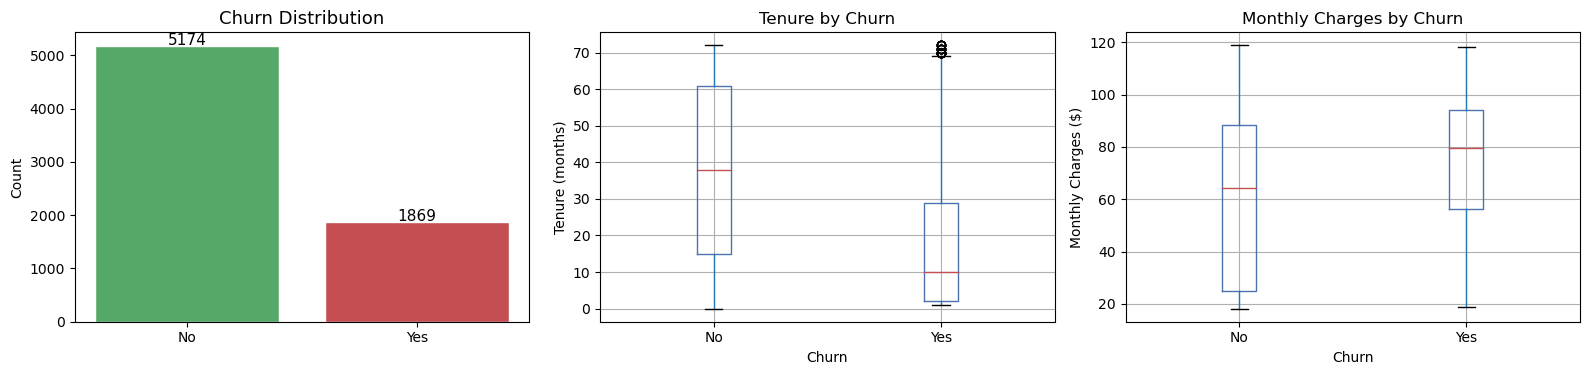

✅ Saved: eda_plots.png


In [4]:
print("=== Dataset Info ===")
print(df.dtypes)
print(f"\nMissing values:\n{df.isnull().sum()[df.isnull().sum() > 0]}")
print(f"\nChurn distribution:\n{df['Churn'].value_counts()}")
print(f"\nChurn rate: {df['Churn'].value_counts(normalize=True)['Yes']*100:.1f}%")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Churn distribution
churn_counts = df["Churn"].value_counts()
axes[0].bar(churn_counts.index, churn_counts.values,
            color=["#55A868", "#C44E52"], edgecolor="white")
axes[0].set_title("Churn Distribution", fontsize=13)
axes[0].set_ylabel("Count")
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 30, str(v), ha="center", fontsize=11)

# Tenure by churn
df.boxplot(column="tenure", by="Churn", ax=axes[1],
           boxprops=dict(color="#4C72B0"),
           medianprops=dict(color="#C44E52"))
axes[1].set_title("Tenure by Churn", fontsize=13)
axes[1].set_xlabel("Churn")
axes[1].set_ylabel("Tenure (months)")
plt.sca(axes[1])
plt.title("Tenure by Churn")

# Monthly charges by churn
df.boxplot(column="MonthlyCharges", by="Churn", ax=axes[2],
           boxprops=dict(color="#4C72B0"),
           medianprops=dict(color="#C44E52"))
axes[2].set_title("Monthly Charges by Churn", fontsize=13)
axes[2].set_xlabel("Churn")
axes[2].set_ylabel("Monthly Charges ($)")
plt.sca(axes[2])
plt.title("Monthly Charges by Churn")

plt.suptitle("")
plt.tight_layout()
plt.savefig("eda_plots.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: eda_plots.png")

In [5]:
# ── Drop irrelevant column ──
df = df.drop(columns=["customerID"])

# ── Fix TotalCharges (has spaces instead of NaN) ───
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

# ── Encode target ──
df["Churn"] = (df["Churn"] == "Yes").astype(int)

# ── Split features / target ──
X = df.drop(columns=["Churn"])
y = df["Churn"]

# ── Identify column types ──
numerical_cols    = ["tenure", "MonthlyCharges", "TotalCharges"]
categorical_cols  = [c for c in X.columns if c not in numerical_cols]

print(f"Numerical  columns ({len(numerical_cols)}): {numerical_cols}")
print(f"Categorical columns ({len(categorical_cols)}): {categorical_cols}")
print(f"\nX shape: {X.shape}")
print(f"y distribution:\n{y.value_counts()}")

# ── Train / test split ──
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTrain: {X_train.shape[0]} | Test: {X_test.shape[0]}")

Numerical  columns (3): ['tenure', 'MonthlyCharges', 'TotalCharges']
Categorical columns (16): ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

X shape: (7043, 19)
y distribution:
0    5174
1    1869
Name: Churn, dtype: int64

Train: 5634 | Test: 1409


In [7]:
# ── Preprocessor ──
preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), numerical_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse=False), categorical_cols),
])

# ── Logistic Regression Pipeline ──
lr_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier",   LogisticRegression(max_iter=1000, random_state=42)),
])

# ── Random Forest Pipeline ──
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier",   RandomForestClassifier(random_state=42)),
])

print("✅ Pipelines created.")
print(f"\nLogistic Regression Pipeline:\n{lr_pipeline}")
print(f"\nRandom Forest Pipeline:\n{rf_pipeline}")

✅ Pipelines created.

Logistic Regression Pipeline:
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['tenure', 'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse=False),
                                                  ['gender', 'SeniorCitizen',
                                                   'Partner', 'Dependents',
                                                   'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                       

In [8]:
# Train both pipelines
print("Training Logistic Regression...")
lr_pipeline.fit(X_train, y_train)

print("Training Random Forest...")
rf_pipeline.fit(X_train, y_train)

# Evaluate
def evaluate(name, pipeline, X_test, y_test):
    preds = pipeline.predict(X_test)
    proba = pipeline.predict_proba(X_test)[:, 1]
    print(f"\n{'═'*45}")
    print(f"  {name}")
    print(f"{'═'*45}")
    print(f"  Accuracy  : {accuracy_score(y_test, preds):.4f}")
    print(f"  F1 Score  : {f1_score(y_test, preds):.4f}")
    print(f"  ROC-AUC   : {roc_auc_score(y_test, proba):.4f}")
    print(f"\n{classification_report(y_test, preds, target_names=['No Churn','Churn'])}")
    return preds, proba

lr_preds, lr_proba = evaluate("Logistic Regression", lr_pipeline, X_test, y_test)
rf_preds, rf_proba = evaluate("Random Forest",       rf_pipeline, X_test, y_test)

Training Logistic Regression...
Training Random Forest...

═════════════════════════════════════════════
  Logistic Regression
═════════════════════════════════════════════
  Accuracy  : 0.8055
  F1 Score  : 0.6040
  ROC-AUC   : 0.8419

              precision    recall  f1-score   support

    No Churn       0.85      0.89      0.87      1035
       Churn       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409


═════════════════════════════════════════════
  Random Forest
═════════════════════════════════════════════
  Accuracy  : 0.7821
  F1 Score  : 0.5370
  ROC-AUC   : 0.8179

              precision    recall  f1-score   support

    No Churn       0.82      0.89      0.86      1035
       Churn       0.62      0.48      0.54       374

    accuracy                           0.78      1409
   macro avg       0.72      0.68      0.70  

In [9]:
# ── Tune Logistic Regression ──
lr_param_grid = {
    "classifier__C"      : [0.01, 0.1, 1, 10],
    "classifier__solver" : ["lbfgs", "liblinear"],
}

print("Running GridSearchCV for Logistic Regression...")
lr_grid = GridSearchCV(
    lr_pipeline, lr_param_grid,
    cv=5, scoring="f1", n_jobs=-1, verbose=1
)
lr_grid.fit(X_train, y_train)
print(f"Best params : {lr_grid.best_params_}")
print(f"Best CV F1  : {lr_grid.best_score_:.4f}")

# ── Tune Random Forest ──
rf_param_grid = {
    "classifier__n_estimators" : [100, 200],
    "classifier__max_depth"    : [None, 10, 20],
    "classifier__min_samples_split": [2, 5],
}

print("\nRunning GridSearchCV for Random Forest...")
rf_grid = GridSearchCV(
    rf_pipeline, rf_param_grid,
    cv=5, scoring="f1", n_jobs=-1, verbose=1
)
rf_grid.fit(X_train, y_train)
print(f"Best params : {rf_grid.best_params_}")
print(f"Best CV F1  : {rf_grid.best_score_:.4f}")

Running GridSearchCV for Logistic Regression...
Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best params : {'classifier__C': 10, 'classifier__solver': 'lbfgs'}
Best CV F1  : 0.5989

Running GridSearchCV for Random Forest...
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best params : {'classifier__max_depth': 10, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 100}
Best CV F1  : 0.5833


In [10]:
print("Results After Hyperparameter Tuning")

lr_tuned_preds, lr_tuned_proba = evaluate("Logistic Regression (Tuned)", lr_grid.best_estimator_, X_test, y_test)
rf_tuned_preds, rf_tuned_proba = evaluate("Random Forest (Tuned)",       rf_grid.best_estimator_, X_test, y_test)

Results After Hyperparameter Tuning

═════════════════════════════════════════════
  Logistic Regression (Tuned)
═════════════════════════════════════════════
  Accuracy  : 0.8048
  F1 Score  : 0.6032
  ROC-AUC   : 0.8411

              precision    recall  f1-score   support

    No Churn       0.85      0.89      0.87      1035
       Churn       0.66      0.56      0.60       374

    accuracy                           0.80      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.80      0.80      1409


═════════════════════════════════════════════
  Random Forest (Tuned)
═════════════════════════════════════════════
  Accuracy  : 0.8062
  F1 Score  : 0.5857
  ROC-AUC   : 0.8400

              precision    recall  f1-score   support

    No Churn       0.84      0.91      0.87      1035
       Churn       0.68      0.52      0.59       374

    accuracy                           0.81      1409
   macro avg       0.76      0.71      0.73      14

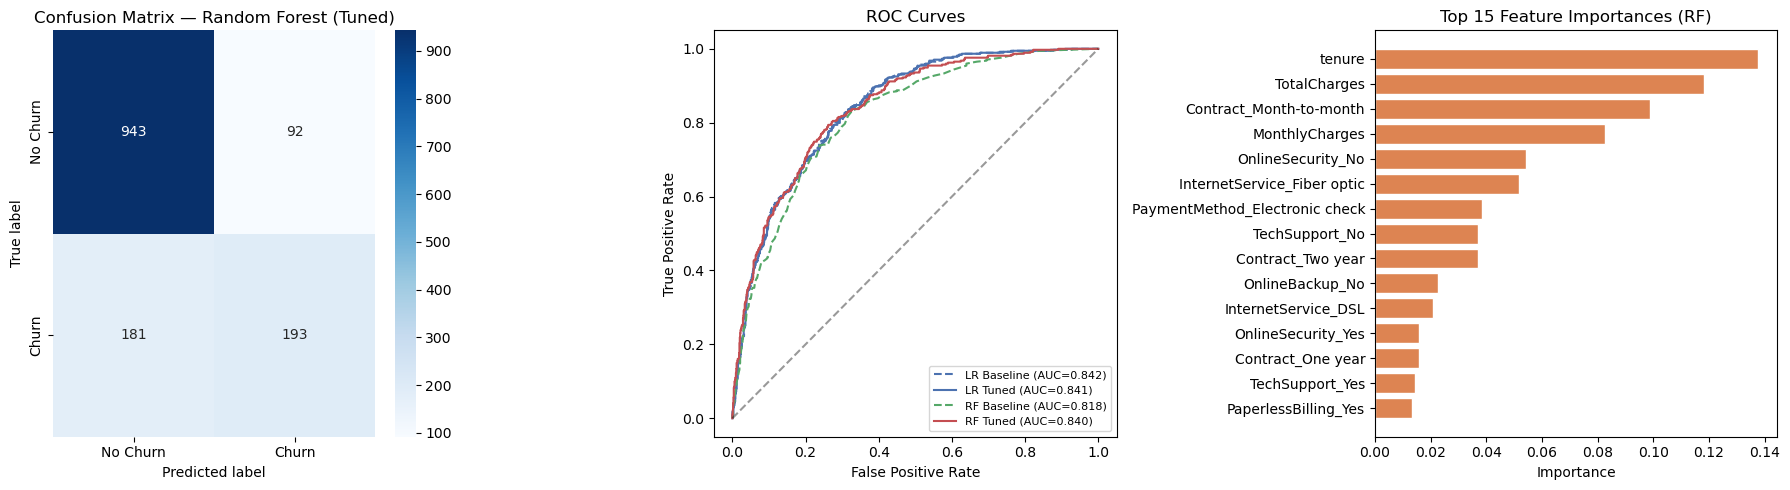

✅ Saved: evaluation_plots.png


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── Confusion matrix — best model (Random Forest) ──
cm = confusion_matrix(y_test, rf_tuned_preds)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Churn","Churn"],
            yticklabels=["No Churn","Churn"], ax=axes[0])
axes[0].set_title("Confusion Matrix — Random Forest (Tuned)", fontsize=12)
axes[0].set_ylabel("True label")
axes[0].set_xlabel("Predicted label")

# ── ROC curves ──
for name, proba, color in [
    ("LR Baseline",  lr_proba,       "#4C72B0"),
    ("LR Tuned",     lr_tuned_proba, "#4C72B0"),
    ("RF Baseline",  rf_proba,       "#55A868"),
    ("RF Tuned",     rf_tuned_proba, "#C44E52"),
]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    ls = "--" if "Baseline" in name else "-"
    axes[1].plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})", color=color, linestyle=ls)
axes[1].plot([0,1],[0,1],"k--", alpha=0.4)
axes[1].set_title("ROC Curves", fontsize=12)
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].legend(fontsize=8)

# ── Feature importance — Random Forest ──
best_rf = rf_grid.best_estimator_
feature_names = (
    numerical_cols +
    list(best_rf.named_steps["preprocessor"]
         .named_transformers_["cat"]
         .get_feature_names_out(categorical_cols))
)
importances = best_rf.named_steps["classifier"].feature_importances_
top_idx = np.argsort(importances)[-15:]

axes[2].barh(
    [feature_names[i] for i in top_idx],
    importances[top_idx],
    color="#DD8452", edgecolor="white"
)
axes[2].set_title("Top 15 Feature Importances (RF)", fontsize=12)
axes[2].set_xlabel("Importance")

plt.tight_layout()
plt.savefig("evaluation_plots.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: evaluation_plots.png")

In [12]:
# Export best model pipeline
best_model = rf_grid.best_estimator_

joblib.dump(best_model, "churn_pipeline.pkl")
print("✅ Pipeline exported: churn_pipeline.pkl")

# Verify it loads and works
loaded_pipeline = joblib.load("churn_pipeline.pkl")
test_preds = loaded_pipeline.predict(X_test)
print(f"   Verification accuracy: {accuracy_score(y_test, test_preds):.4f}")
print(f"   Pipeline steps: {[s[0] for s in loaded_pipeline.steps]}")

✅ Pipeline exported: churn_pipeline.pkl
   Verification accuracy: 0.8062
   Pipeline steps: ['preprocessor', 'classifier']


In [13]:
%%writefile .gitignore
__pycache__/
*.pyc
.ipynb_checkpoints/
venv/
.env
*.log

Writing .gitignore
